# QKD-Secured Pairwise-Masked Federated Learning for RadioML 2018.01A

This notebook mirrors the pairwise QKD-FL workflow used in your channel-estimation and radar notebooks, adapted for modulation classification.

- Experiment A: plain vs Classical-SA vs QKD-SA (utility + communication/compute overhead)
- Experiment B: threat model with Eve (QBER-based abort)
- Experiment C: QBER sensitivity to channel noise
- Publication-ready plots and tables

In [1]:
# SECTION 1 — Imports, Device, Global Config

import os
import time
import math
import copy
import random
import hashlib
from datetime import datetime

import numpy as np
import pandas as pd
import h5py
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, Subset

import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split

if torch.backends.mps.is_available():
    device = torch.device('mps')
elif torch.cuda.is_available():
    device = torch.device('cuda')
else:
    device = torch.device('cpu')
print(f'Using device: {device}')

# Data
DATA_PATH = 'data/radioml/GOLD_XYZ_OSC.0001_1024.hdf5'
SAMPLE_CACHE_PATH = 'data/radioml/radioml_sample.npz'
SAMPLES_PER_BIN = 64

# Training / FL / QKD
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
SEED = 42
NUM_ROUNDS = 5
LOCAL_EPOCHS = 10
KEY_BIT_LENGTH = 2000
QBER_THRESHOLD = 0.08
MASK_SCALE = 1e-3
PA_RATIO = 0.8
K_VALS = [3, 10, 20]
MODES = ['plain', 'classical_sa', 'qkd_sa']

RUN_ID = datetime.now().strftime('%Y%m%d_%H%M%S')
RESULTS_DIR = os.path.join('outputs', 'radioml_qkd_pairwise', RUN_ID)
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(os.path.join(RESULTS_DIR, 'pub'), exist_ok=True)

CLASS_NAMES = [
    'OOK','4ASK','8ASK','BPSK','QPSK','8PSK','16PSK','32PSK',
    '16APSK','32APSK','64APSK','128APSK',
    '16QAM','32QAM','64QAM','128QAM','256QAM',
    'AM-SSB-WC','AM-SSB-SC','AM-DSB-WC','AM-DSB-SC',
    'FM','GMSK','OQPSK'
]
NUM_CLASSES = len(CLASS_NAMES)


def set_global_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_global_seed()
print(f'RUN_ID={RUN_ID}')
print(f'RESULTS_DIR={RESULTS_DIR}')

Using device: mps
RUN_ID=20260420_090525
RESULTS_DIR=outputs/radioml_qkd_pairwise/20260420_090525


In [2]:
# SECTION 2 — RadioML dataset loader and client partitioning

class RadioMLDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
    def __len__(self):
        return len(self.X)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]


def make_stratified_sample(path, samples_per_bin=64, seed=42):
    with h5py.File(path, 'r') as f:
        X_full = f['X'][:]          # (N,1024,2)
        Y_full = f['Y'][:]          # (N,24)
        snr_full = f['Z'][:].flatten()

    y_full = np.argmax(Y_full, axis=1).astype(np.int64)
    X_full = X_full.transpose(0, 2, 1).astype(np.float32)  # (N,2,1024)

    rng = np.random.default_rng(seed)
    keep_idx = []
    snr_levels = np.unique(snr_full)
    for cls in range(Y_full.shape[1]):
        for snr_val in snr_levels:
            idx = np.where((y_full == cls) & (snr_full == snr_val))[0]
            if len(idx) == 0:
                continue
            chosen = rng.choice(idx, size=min(samples_per_bin, len(idx)), replace=False)
            keep_idx.extend(chosen.tolist())

    keep_idx = np.array(keep_idx)
    rng.shuffle(keep_idx)
    return X_full[keep_idx], y_full[keep_idx], snr_full[keep_idx]


def load_radioml_cached():
    os.makedirs(os.path.dirname(SAMPLE_CACHE_PATH), exist_ok=True)
    if os.path.exists(SAMPLE_CACHE_PATH):
        z = np.load(SAMPLE_CACHE_PATH)
        X_all, y_all, snr_all = z['X'], z['y'], z['snr']
    else:
        if not os.path.exists(DATA_PATH):
            raise FileNotFoundError(f'Missing DATA_PATH: {DATA_PATH}')
        X_all, y_all, snr_all = make_stratified_sample(DATA_PATH, SAMPLES_PER_BIN, SEED)
        np.savez_compressed(SAMPLE_CACHE_PATH, X=X_all, y=y_all, snr=snr_all)
    return X_all, y_all, snr_all


X_all, y_all, snr_all = load_radioml_cached()
idx = np.arange(len(X_all))
idx_tv, idx_test = train_test_split(idx, test_size=0.10, random_state=SEED, stratify=y_all)
idx_train, idx_val = train_test_split(idx_tv, test_size=0.111, random_state=SEED, stratify=y_all[idx_tv])

train_ds = RadioMLDataset(X_all[idx_train], y_all[idx_train])
val_ds = RadioMLDataset(X_all[idx_val], y_all[idx_val])
test_ds = RadioMLDataset(X_all[idx_test], y_all[idx_test])

val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f'Splits: train={len(train_ds):,}, val={len(val_ds):,}, test={len(test_ds):,}')


def partition_dataset_indices(y, K, seed=42):
    # Non-IID partition by sorting (label, snr-like proxy from index randomness)
    rng = np.random.default_rng(seed)
    idx = np.arange(len(y))
    jitter = rng.normal(scale=0.01, size=len(y))
    proxy = y.astype(np.float32) + jitter
    shards = np.array_split(idx[np.argsort(proxy)], K)
    return [s for s in shards if len(s) > 0]


def build_client_loaders(train_dataset, K, seed=42):
    y = train_dataset.y.numpy()
    shards = partition_dataset_indices(y, K, seed=seed)
    loaders = []
    for s in shards[:K]:
        subset = Subset(train_dataset, s.tolist())
        loaders.append(DataLoader(subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0))
    return loaders

Splits: train=31,952, val=3,990, test=3,994


In [3]:
# SECTION 3 — RadioML model + train/eval helpers

class SEBlock1D(nn.Module):
    def __init__(self, channels, reduction=8):
        super().__init__()
        hidden = max(channels // reduction, 8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Sequential(
            nn.Linear(channels, hidden),
            nn.ReLU(inplace=True),
            nn.Linear(hidden, channels),
            nn.Sigmoid(),
        )

    def forward(self, x):
        b, c, _ = x.shape
        w = self.pool(x).view(b, c)
        w = self.fc(w).view(b, c, 1)
        return x * w


class ResBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel=7, stride=1, dropout=0.2):
        super().__init__()
        pad = kernel // 2
        self.conv1 = nn.Conv1d(in_ch, out_ch, kernel, stride=stride, padding=pad, bias=False)
        self.bn1 = nn.BatchNorm1d(out_ch)
        self.conv2 = nn.Conv1d(out_ch, out_ch, kernel, padding=pad, bias=False)
        self.bn2 = nn.BatchNorm1d(out_ch)
        self.se = SEBlock1D(out_ch)
        self.act = nn.GELU()
        self.drop = nn.Dropout(dropout)
        self.proj = None
        if in_ch != out_ch or stride != 1:
            self.proj = nn.Sequential(
                nn.Conv1d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm1d(out_ch),
            )

    def forward(self, x):
        identity = x if self.proj is None else self.proj(x)
        out = self.act(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        out = self.se(out)
        out = self.drop(out)
        return self.act(out + identity)


class RadioMLNet(nn.Module):
    def __init__(self, num_classes=24):
        super().__init__()
        self.stem_k3 = nn.Conv1d(2, 24, 3, padding=1, bias=False)
        self.stem_k7 = nn.Conv1d(2, 24, 7, padding=3, bias=False)
        self.stem_k11 = nn.Conv1d(2, 24, 11, padding=5, bias=False)
        self.stem_fuse = nn.Sequential(
            nn.BatchNorm1d(72), nn.GELU(), nn.Conv1d(72, 96, 1, bias=False), nn.BatchNorm1d(96), nn.GELU()
        )
        self.stage1 = ResBlock1D(96, 128, 7, stride=2, dropout=0.15)
        self.stage2 = ResBlock1D(128, 192, 5, stride=2, dropout=0.20)
        self.stage3 = ResBlock1D(192, 256, 3, stride=2, dropout=0.25)
        self.bilstm = nn.LSTM(256, 128, num_layers=1, bidirectional=True, batch_first=True)
        self.attn = nn.Linear(256, 1)
        self.classifier = nn.Sequential(nn.Linear(768, 256), nn.GELU(), nn.Dropout(0.4), nn.Linear(256, num_classes))

    def forward(self, x):
        x = torch.cat([self.stem_k3(x), self.stem_k7(x), self.stem_k11(x)], dim=1)
        x = self.stem_fuse(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = x.transpose(1, 2)
        x, _ = self.bilstm(x)
        attn_w = torch.softmax(self.attn(x), dim=1)
        attn_pool = torch.sum(attn_w * x, dim=1)
        mean_pool = torch.mean(x, dim=1)
        std_pool = torch.std(x, dim=1, unbiased=False)
        return self.classifier(torch.cat([attn_pool, mean_pool, std_pool], dim=1))


def train_client(model, loader, epochs=LOCAL_EPOCHS, lr=LEARNING_RATE):
    model.train()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=5e-4)
    crit = nn.CrossEntropyLoss(label_smoothing=0.02)
    for _ in range(epochs):
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            opt.zero_grad()
            logits = model(X)
            loss = crit(logits, y)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    return {k: v.detach().cpu() for k, v in model.state_dict().items()}


@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    crit = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        logits = model(X)
        loss = crit(logits, y)
        total_loss += loss.item() * len(y)
        correct += (logits.argmax(1) == y).sum().item()
        total += len(y)
    return {'loss': total_loss / max(total, 1), 'acc': correct / max(total, 1)}


def average_state_dicts(state_dicts, dev):
    avg = {}
    keys = state_dicts[0].keys()
    for k in keys:
        tensors = [sd[k].float().to(dev) for sd in state_dicts]
        avg[k] = torch.stack(tensors, dim=0).mean(dim=0).detach().cpu()
    return avg

print('Model and helpers ready.')

Model and helpers ready.


In [4]:
# SECTION 4 — BB84-style abstraction + pairwise masking

def _privacy_amplify(bits, final_len):
    bits = list(bits)
    out = []
    ctr = 0
    while len(out) < final_len:
        msg = ''.join(str(b) for b in bits[:1024]) + f'|{len(bits)}|{ctr}'
        h = hashlib.sha256(msg.encode()).digest()
        for byte in h:
            for k in range(8):
                if len(out) < final_len:
                    out.append((byte >> (7-k)) & 1)
        ctr += 1
    return out


def generate_bb84_abstraction_key(bit_length, seed=None, pa_ratio=0.8, eve_present=False, channel_noise=0.0):
    if seed is not None:
        random.seed(seed)
        np.random.seed(seed)

    alice_bits = [random.randint(0, 1) for _ in range(bit_length)]
    alice_bases = [random.randint(0, 1) for _ in range(bit_length)]
    bob_bases = [random.randint(0, 1) for _ in range(bit_length)]
    eve_bases = [random.randint(0, 1) for _ in range(bit_length)] if eve_present else None

    bob_bits = []
    for i in range(bit_length):
        if eve_present:
            eve_bit = alice_bits[i] if eve_bases[i] == alice_bases[i] else random.randint(0, 1)
            bob_bit = eve_bit if bob_bases[i] == eve_bases[i] else random.randint(0, 1)
        else:
            bob_bit = alice_bits[i] if bob_bases[i] == alice_bases[i] else random.randint(0, 1)
        if channel_noise > 0 and random.random() < channel_noise:
            bob_bit = 1 - bob_bit
        bob_bits.append(bob_bit)

    sift_idx = [i for i in range(bit_length) if alice_bases[i] == bob_bases[i]]
    a_s = [alice_bits[i] for i in sift_idx]
    b_s = [bob_bits[i] for i in sift_idx]
    sifted_len = len(sift_idx)
    qber = (sum(int(a != b) for a, b in zip(a_s, b_s)) / sifted_len) if sifted_len else 0.0
    final_len = max(256, int(pa_ratio * sifted_len))
    return _privacy_amplify(a_s, final_len), _privacy_amplify(b_s, final_len), sifted_len, final_len, qber


def derive_pairwise_key_classical(i, j, round_id, base_seed, bit_length):
    lo, hi = min(i, j), max(i, j)
    seed = f'{base_seed}|{round_id}|{lo}|{hi}'
    out, ctr = [], 0
    while len(out) < bit_length:
        h = hashlib.sha256((seed + f'|{ctr}').encode()).digest()
        for byte in h:
            for k in range(8):
                if len(out) < bit_length:
                    out.append((byte >> (7-k)) & 1)
        ctr += 1
    return out


def derive_pairwise_key_qkd(round_key_bits, i, j, bit_length):
    lo, hi = min(i, j), max(i, j)
    seed = ''.join(map(str, round_key_bits[:512])) + f'|{lo}|{hi}'
    out, ctr = [], 0
    while len(out) < bit_length:
        h = hashlib.sha256((seed + f'|{ctr}').encode()).digest()
        for byte in h:
            for k in range(8):
                if len(out) < bit_length:
                    out.append((byte >> (7-k)) & 1)
        ctr += 1
    return out


def mask_from_bits(bits, shape, scale=1e-3, dev=None):
    arr = np.array([1.0 if b else -1.0 for b in bits], dtype=np.float32)
    n = int(np.prod(shape))
    if len(arr) < n:
        reps = int(np.ceil(n / len(arr)))
        arr = np.tile(arr, reps)
    arr = arr[:n].reshape(shape) * scale
    # Use as_tensor to support both ndarray and scalar numpy outputs.
    t = torch.as_tensor(arr, dtype=torch.float32)
    return t.to(dev) if dev is not None else t


def apply_pairwise_masks(local_state_dict, client_id, round_id, num_clients, bit_length, dev,
                         key_source='classical', base_seed=123, round_key_bits=None):
    masked = {}
    for n, p in local_state_dict.items():
        mp = p.detach().clone().float().to(dev)
        for j in range(num_clients):
            if j == client_id:
                continue
            if key_source == 'classical':
                bits = derive_pairwise_key_classical(client_id, j, round_id, base_seed, bit_length)
            else:
                bits = derive_pairwise_key_qkd(round_key_bits, client_id, j, bit_length)
            m = mask_from_bits(bits, p.shape, scale=MASK_SCALE, dev=dev)
            mp = mp + m if client_id < j else mp - m
        masked[n] = mp.detach().cpu()
    return masked


def model_size_bytes(model_or_sd):
    sd = model_or_sd if isinstance(model_or_sd, dict) else model_or_sd.state_dict()
    return int(sum(v.numel() * v.element_size() for v in sd.values()))

print('QKD and masking helpers ready.')

QKD and masking helpers ready.


In [5]:
# SECTION 5 — FL experiment runner (TVT style)

def run_experiment_tvt(mode, K, R, E, client_loaders, val_loader, key_bits=KEY_BIT_LENGTH, base_seed=123,
                       eve_every_round=False, channel_noise=0.0):
    global_model = RadioMLNet(NUM_CLASSES).to(device)
    model_bytes = model_size_bytes(global_model)

    round_acc, round_loss = [], []
    round_metrics, qber_hist = [], []
    abort_count = 0
    had_abort = False

    for r in tqdm(range(R), desc=f'Round ({mode}, K={K})', leave=False):
        t_round = time.perf_counter()

        round_key_bits = None
        qber = 0.0
        t_keygen = 0.0
        if mode == 'qkd_sa':
            t0 = time.perf_counter()
            alice_key, bob_key, sifted, final_len, qber = generate_bb84_abstraction_key(
                bit_length=key_bits,
                seed=r * 37 + base_seed,
                pa_ratio=PA_RATIO,
                eve_present=eve_every_round,
                channel_noise=channel_noise,
            )
            t_keygen = time.perf_counter() - t0
            round_key_bits = alice_key
            qber_hist.append(qber)

            if qber >= QBER_THRESHOLD:
                abort_count += 1
                had_abort = True
                m = evaluate(global_model, val_loader)
                round_acc.append(m['acc'])
                round_loss.append(m['loss'])
                round_metrics.append({
                    'round': r,
                    'acc': m['acc'],
                    'loss': m['loss'],
                    'bytes_downlink': model_bytes,
                    'bytes_uplink_total': 0,
                    'masking_time_per_client': 0.0,
                    'keygen_time_per_client': t_keygen / K,
                    'round_wall_time': time.perf_counter() - t_round,
                    'status': 'ABORTED',
                    'qber': qber,
                })
                continue

        client_states = []
        mask_times = []
        bytes_uplink_total = 0

        for c in range(K):
            cm = RadioMLNet(NUM_CLASSES).to(device)
            cm.load_state_dict(global_model.state_dict())
            local_sd = train_client(cm, client_loaders[c], epochs=E)

            if mode == 'plain':
                payload = local_sd
                mask_times.append(0.0)
            else:
                t_mask = time.perf_counter()
                payload = apply_pairwise_masks(
                    local_sd, c, r, K, key_bits, device,
                    key_source='classical' if mode == 'classical_sa' else 'qkd',
                    base_seed=base_seed,
                    round_key_bits=round_key_bits,
                )
                mask_times.append(time.perf_counter() - t_mask)

            client_states.append(payload)
            bytes_uplink_total += model_size_bytes(payload)

        avg = average_state_dicts(client_states, device)
        global_model.load_state_dict(avg)
        m = evaluate(global_model, val_loader)

        round_acc.append(m['acc'])
        round_loss.append(m['loss'])
        round_metrics.append({
            'round': r,
            'acc': m['acc'],
            'loss': m['loss'],
            'bytes_downlink': model_bytes,
            'bytes_uplink_total': bytes_uplink_total,
            'masking_time_per_client': float(np.mean(mask_times)),
            'keygen_time_per_client': (t_keygen / K) if mode == 'qkd_sa' else 0.0,
            'round_wall_time': time.perf_counter() - t_round,
            'status': 'RECOVERED' if had_abort else 'SECURE',
            'qber': qber,
        })

    return {
        'round_acc': round_acc,
        'round_loss': round_loss,
        'round_metrics': round_metrics,
        'qber_history': qber_hist,
        'abort_count': abort_count,
        'model_bytes': model_bytes,
    }

In [6]:
# SECTION 6 — Experiment A (K sweep, plain/classical_sa/qkd_sa)

all_results = []
full_results = {}

for K in K_VALS:
    loaders_k = build_client_loaders(train_ds, K, seed=SEED)
    if len(loaders_k) < K:
        print(f'Skipping K={K}, got {len(loaders_k)} clients only.')
        continue

    for mode in MODES:
        print(f'Running A: K={K}, mode={mode}')
        res = run_experiment_tvt(mode, K, NUM_ROUNDS, LOCAL_EPOCHS, loaders_k, val_loader)
        full_results[(K, mode)] = res
        for rr in res['round_metrics']:
            all_results.append({
                'K': K,
                'mode': mode,
                'round': rr['round'],
                'acc': rr['acc'],
                'loss': rr['loss'],
                'bytes_downlink': rr['bytes_downlink'],
                'bytes_uplink_total': rr['bytes_uplink_total'],
                'masking_time': rr['masking_time_per_client'],
                'keygen_time': rr['keygen_time_per_client'],
                'round_wall_time': rr['round_wall_time'],
                'status': rr['status'],
                'qber': rr['qber'],
            })

df_rounds_a = pd.DataFrame(all_results)

summary_rows = []
for K in K_VALS:
    for mode in MODES:
        sub = df_rounds_a[(df_rounds_a['K'] == K) & (df_rounds_a['mode'] == mode)]
        if len(sub) == 0:
            continue
        final = sub[sub['round'] == sub['round'].max()].iloc[0]
        summary_rows.append({
            'K': K,
            'mode': mode,
            'final_acc': final['acc'],
            'final_loss': final['loss'],
            'bytes_downlink': final['bytes_downlink'],
            'bytes_uplink_total': final['bytes_uplink_total'],
            'mean_masking_time': sub['masking_time'].mean(),
            'mean_keygen_time': sub['keygen_time'].mean(),
            'mean_round_time': sub['round_wall_time'].mean(),
            'abort_rate': (sub['status'] == 'ABORTED').mean(),
            'mean_qber': sub['qber'].mean() if mode == 'qkd_sa' else np.nan,
        })

df_summary_a = pd.DataFrame(summary_rows)
print(df_summary_a.to_string(index=False))

df_rounds_a.to_csv(os.path.join(RESULTS_DIR, 'experiment_A_rounds.csv'), index=False)
df_summary_a.to_csv(os.path.join(RESULTS_DIR, 'experiment_A_summary.csv'), index=False)
print('Saved Experiment A tables.')

Running A: K=3, mode=plain


Round (plain, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Running A: K=3, mode=classical_sa


Round (classical_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Running A: K=3, mode=qkd_sa


...

Running A: K=20, mode=classical_sa


Round (classical_sa, K=20):   0%|          | 0/5 [00:00<?, ?it/s]

Running A: K=20, mode=qkd_sa


Round (qkd_sa, K=20):   0%|          | 0/5 [00:00<?, ?it/s]

 K         mode  final_acc  final_loss  bytes_downlink  bytes_uplink_total  mean_masking_time  mean_keygen_time  mean_round_time  abort_rate  mean_qber
 3        plain   0.105764    3.127597         6329628            18988884           0.000000          0.000000       597.314683         0.0        NaN
 3 classical_sa   0.156140    3.055111         6329628            18988752           0.204749          0.000000       600.906067         0.0        NaN
 3       qkd_sa   0.151378    3.171074         6329628            18988752           0.209669          0.002700       621.819118         0.0        0.0
10        plain   0.056140    3.408972         6329628            63296280           0.000000          0.000000       594.680289         0.0        NaN
10 classical_sa   0.041604    3.385037         6329628            63295840           0.714824          0.000000       617.901039         0.0        NaN
10       qkd_sa   0.042857    3.218971         6329628            63295840           0.7

In [7]:
# SECTION 7 — Experiment B (threat model with Eve)

K_B = 3
client_loaders_b = build_client_loaders(train_ds, K_B, seed=SEED)

exp_b_secure = run_experiment_tvt('qkd_sa', K_B, NUM_ROUNDS, LOCAL_EPOCHS, client_loaders_b, val_loader,
                                  eve_every_round=False, channel_noise=0.0)
exp_b_eve = run_experiment_tvt('qkd_sa', K_B, NUM_ROUNDS, LOCAL_EPOCHS, client_loaders_b, val_loader,
                               eve_every_round=True, channel_noise=0.0)

threat_rows = [
    {
        'mode': 'secure',
        'rounds': NUM_ROUNDS,
        'aborted': exp_b_secure['abort_count'],
        'mean_qber': np.mean(exp_b_secure['qber_history']) if len(exp_b_secure['qber_history']) else 0.0,
        'final_acc': exp_b_secure['round_acc'][-1],
    },
    {
        'mode': 'eve_all_rounds',
        'rounds': NUM_ROUNDS,
        'aborted': exp_b_eve['abort_count'],
        'mean_qber': np.mean(exp_b_eve['qber_history']) if len(exp_b_eve['qber_history']) else 0.0,
        'final_acc': exp_b_eve['round_acc'][-1],
    },
]

df_threat_b = pd.DataFrame(threat_rows)
print(df_threat_b.to_string(index=False))
df_threat_b.to_csv(os.path.join(RESULTS_DIR, 'experiment_B_threat.csv'), index=False)
print('Saved Experiment B table.')

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

          mode  rounds  aborted  mean_qber  final_acc
        secure       5        0   0.000000   0.156642
eve_all_rounds       5        5   0.245952   0.041604
Saved Experiment B table.


In [8]:
# SECTION 8 — Experiment C (QBER sensitivity)

noise_levels = np.linspace(0.0, 0.20, 9)
rows_c = []

K_C = 3
client_loaders_c = build_client_loaders(train_ds, K_C, seed=SEED)

for eta in noise_levels:
    res = run_experiment_tvt('qkd_sa', K_C, NUM_ROUNDS, LOCAL_EPOCHS, client_loaders_c, val_loader,
                             eve_every_round=False, channel_noise=float(eta))
    rows_c.append({
        'noise': float(eta),
        'mean_qber': float(np.mean(res['qber_history'])) if len(res['qber_history']) else 0.0,
        'abort_count': int(res['abort_count']),
    })

df_exp_c = pd.DataFrame(rows_c)
print(df_exp_c.to_string(index=False))
df_exp_c.to_csv(os.path.join(RESULTS_DIR, 'experiment_C_qber_sensitivity.csv'), index=False)
print('Saved Experiment C table.')

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

Round (qkd_sa, K=3):   0%|          | 0/5 [00:00<?, ?it/s]

 noise  mean_qber  abort_count
 0.000   0.000000            0
 0.025   0.024160            0
 0.050   0.052260            0
 0.075   0.075020            2
 0.100   0.101475            5
 0.125   0.122446            5
 0.150   0.147208            5
 0.175   0.175010            5
 0.200   0.201821            5
Saved Experiment C table.


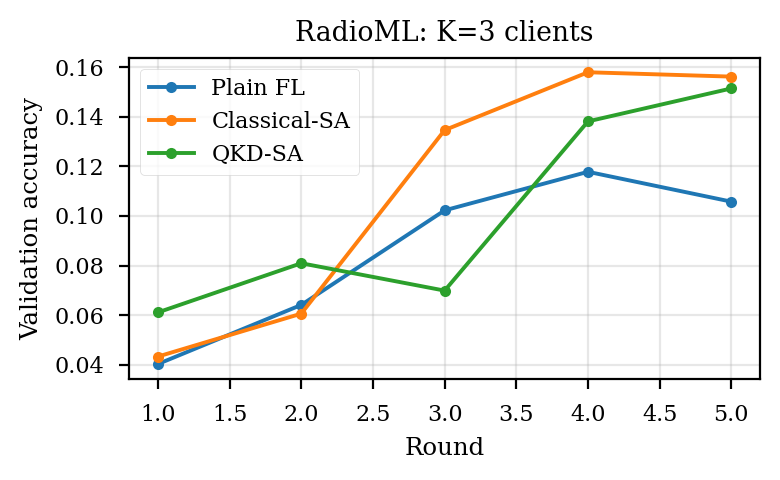

Saved: outputs/radioml_qkd_pairwise/20260420_090525/pub/radioml_learning_curve_K3.pdf


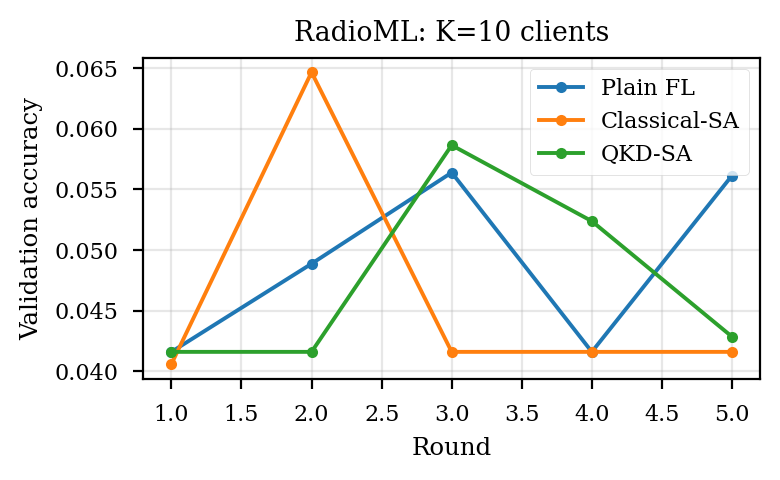

Saved: outputs/radioml_qkd_pairwise/20260420_090525/pub/radioml_learning_curve_K10.pdf


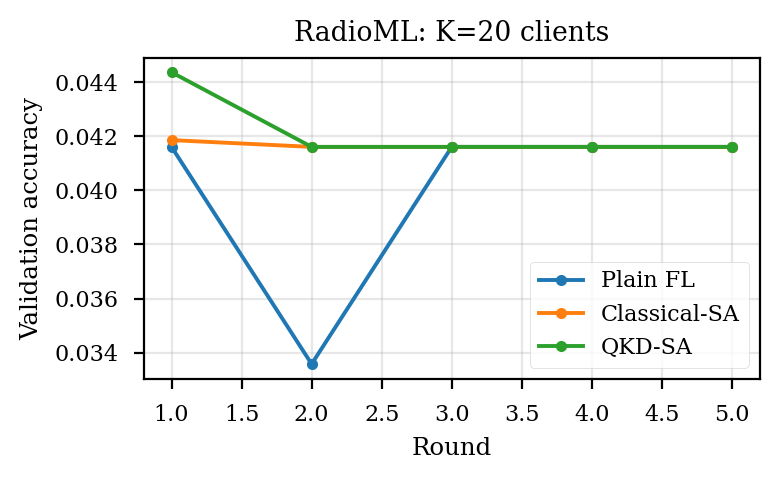

Saved: outputs/radioml_qkd_pairwise/20260420_090525/pub/radioml_learning_curve_K20.pdf


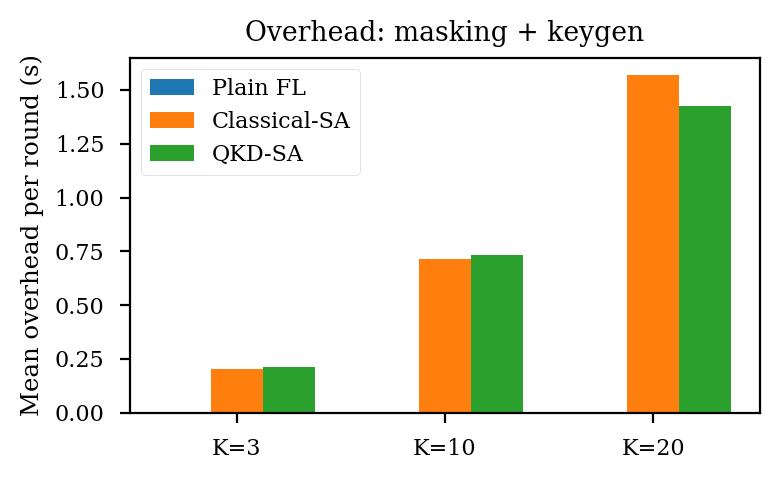

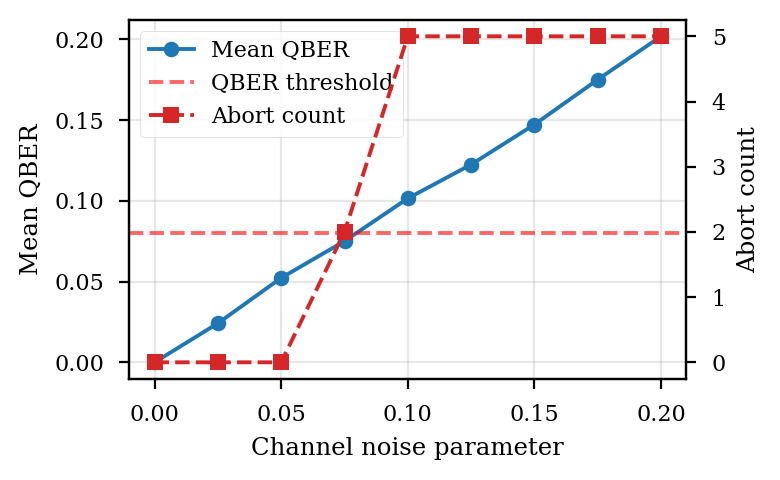

Saved publication figures/tables to: outputs/radioml_qkd_pairwise/20260420_090525/pub

Table A (utility + communication):
 K         mode  final_acc  bytes_downlink  bytes_uplink_total  mean_round_time
 3        plain   0.105764         6329628            18988884       597.314683
 3 classical_sa   0.156140         6329628            18988752       600.906067
 3       qkd_sa   0.151378         6329628            18988752       621.819118
10        plain   0.056140         6329628            63296280       594.680289
10 classical_sa   0.041604         6329628            63295840       617.901039
10       qkd_sa   0.042857         6329628            63295840       607.365710
20        plain   0.041604         6329628           126592560       606.001099
20 classical_sa   0.041604         6329628           126591680       676.652601
20       qkd_sa   0.041604         6329628           126591680       657.266475

Table B (threat model):
          mode  rounds  aborted  mean_qber  final_acc

In [9]:
# SECTION 9 — Publication-ready plots and table exports

try:
    plt.style.use('seaborn-v0_8-paper')
except OSError:
    try:
        plt.style.use('seaborn-paper')
    except OSError:
        pass

plt.rc('text', usetex=False)
plt.rc('font', family='serif')

PUB_DIR = os.path.join(RESULTS_DIR, 'pub')
os.makedirs(PUB_DIR, exist_ok=True)

mode_labels = {'plain': 'Plain FL', 'classical_sa': 'Classical-SA', 'qkd_sa': 'QKD-SA'}

# Figure A1: Learning curve (accuracy vs round) for each K
for K in K_VALS:
    fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200)
    for mode in MODES:
        key = (K, mode)
        if key not in full_results:
            continue
        vals = full_results[key]['round_acc']
        ax.plot(range(1, len(vals) + 1), vals, 'o-', label=mode_labels[mode], markersize=4)
    ax.set_xlabel('Round')
    ax.set_ylabel('Validation accuracy')
    ax.set_title(f'RadioML: K={K} clients')
    ax.grid(True, alpha=0.3)
    ax.legend()
    fig.tight_layout()

    # Keep legacy file name and add learning-curve naming for consistency
    fig.savefig(os.path.join(PUB_DIR, f'radioml_acc_curve_K{K}.pdf'), bbox_inches='tight', dpi=300)
    fig.savefig(os.path.join(PUB_DIR, f'radioml_learning_curve_K{K}.pdf'), bbox_inches='tight', dpi=300)
    plt.show()
    print(f"Saved: {os.path.join(PUB_DIR, f'radioml_learning_curve_K{K}.pdf')}")

# Figure A2: Overhead (masking + keygen)
fig, ax = plt.subplots(figsize=(4, 2.5), dpi=200)
x = np.arange(len(K_VALS))
width = 0.25
for i, mode in enumerate(MODES):
    vals = []
    for K in K_VALS:
        sub = df_rounds_a[(df_rounds_a['K'] == K) & (df_rounds_a['mode'] == mode)]
        vals.append((sub['masking_time'] + sub['keygen_time']).mean() if len(sub) else 0.0)
    ax.bar(x + i * width, vals, width=width, label=mode_labels[mode])
ax.set_xticks(x + width)
ax.set_xticklabels([f'K={k}' for k in K_VALS])
ax.set_ylabel('Mean overhead per round (s)')
ax.set_title('Overhead: masking + keygen')
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(PUB_DIR, 'radioml_overhead_mask_keygen.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# Figure C: QBER sensitivity + abort count
fig, ax1 = plt.subplots(figsize=(4, 2.5), dpi=200)
ax1.plot(df_exp_c['noise'], df_exp_c['mean_qber'], 'o-', color='tab:blue', label='Mean QBER')
ax1.axhline(QBER_THRESHOLD, color='red', linestyle='--', alpha=0.6, label='QBER threshold')
ax1.set_xlabel('Channel noise parameter')
ax1.set_ylabel('Mean QBER')
ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(df_exp_c['noise'], df_exp_c['abort_count'], 's--', color='tab:red', label='Abort count')
ax2.set_ylabel('Abort count')

l1, lb1 = ax1.get_legend_handles_labels()
l2, lb2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lb1 + lb2, loc='best')
fig.tight_layout()
fig.savefig(os.path.join(PUB_DIR, 'radioml_qber_sensitivity.pdf'), bbox_inches='tight', dpi=300)
plt.show()

# Table exports
paper_table_a = df_summary_a[['K', 'mode', 'final_acc', 'bytes_downlink', 'bytes_uplink_total', 'mean_round_time']].copy()
paper_table_b = df_threat_b.copy()
paper_table_c = df_exp_c.copy()

paper_table_a.to_csv(os.path.join(PUB_DIR, 'table_radioml_experiment_A.csv'), index=False)
paper_table_b.to_csv(os.path.join(PUB_DIR, 'table_radioml_experiment_B.csv'), index=False)
paper_table_c.to_csv(os.path.join(PUB_DIR, 'table_radioml_experiment_C.csv'), index=False)

print('Saved publication figures/tables to:', PUB_DIR)
print('\nTable A (utility + communication):')
print(paper_table_a.to_string(index=False))
print('\nTable B (threat model):')
print(paper_table_b.to_string(index=False))